# ROGII - Wellbore Geology Prediction EDA

This notebook is a starter exploration for the **ROGII - Wellbore Geology Prediction** Kaggle competition.

The competition asks us to predict **TVT** (`True Vertical Thickness`) for the hidden/evaluation part of each horizontal well. Each well is a sequence along measured depth (`MD`). Before the prediction start, Kaggle provides `TVT_input`, which is a copy of the known target. After the prediction start, `TVT_input` becomes missing and the model must infer the missing geological position.

The main data sources are:

- Horizontal well trajectory and log data: `MD`, `X`, `Y`, `Z`, `GR`, `TVT_input`, and in training also `TVT` plus geological surface columns.
- A paired vertical reference log, called a **Typewell**, with `TVT` and `GR` that helps correlate gamma ray signatures.
- Optional PNG visualizations for training wells.

The evaluation metric is RMSE on predicted `tvt` values.

## 1. Setup

The path helper below works both in a Kaggle Notebook and in a local extracted copy of the competition data. It expects the competition files to contain `train/`, `test/`, and `sample_submission.csv`.

In [1]:
from pathlib import Path
from collections import Counter
import math
import os
import re
import warnings

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import display, Markdown

warnings.filterwarnings("ignore")
pd.set_option("display.max_columns", 100)
pd.set_option("display.max_colwidth", 120)

try:
    import seaborn as sns
    sns.set_theme(style="whitegrid")
    HAS_SEABORN = True
except Exception:
    HAS_SEABORN = False
    plt.style.use("ggplot")

RANDOM_STATE = 42

In [2]:
def find_data_root():
    candidates = [
        Path("/kaggle/input/competitions/rogii-wellbore-geology-prediction"),
        Path.cwd(),
    ]

    # Also check parents of the current working directory.
    candidates.extend(Path.cwd().parents)

    for root in candidates:
        if (root / "train").is_dir() and (root / "sample_submission.csv").is_file():
            return root.resolve()

    raise FileNotFoundError(
        "Could not find competition data. Expected train/, test/, and sample_submission.csv."
    )

DATA_ROOT = find_data_root()
TRAIN_DIR = DATA_ROOT / "train"
TEST_DIR = DATA_ROOT / "test"
SAMPLE_SUB_PATH = DATA_ROOT / "sample_submission.csv"

print(f"DATA_ROOT = {DATA_ROOT}")
print(f"TRAIN_DIR = {TRAIN_DIR}")
print(f"TEST_DIR  = {TEST_DIR}")

DATA_ROOT = /kaggle/input/competitions/rogii-wellbore-geology-prediction
TRAIN_DIR = /kaggle/input/competitions/rogii-wellbore-geology-prediction/train
TEST_DIR  = /kaggle/input/competitions/rogii-wellbore-geology-prediction/test


## 2. Task Deck Notes

The competition includes `AI_wellbore_geology_prediction_task_en.pptx`, which is worth reading before modeling. The key points from the deck are:

- The goal is to calculate `TVT` beyond the prediction start using horizontal-well `XYZ` and `GR`, plus Typewell `TVT` and `GR`.
- Horizontal `GR` should be correlated against Typewell `GR` on the TVT scale.
- `TVT` is not guaranteed to move in one direction. It can increase, decrease, or stay nearly constant along the horizontal well.
- The horizontal well's known segment before prediction start can be very valuable, because its `GR` may align better with the later lateral than the Typewell alone.
- Neighboring wells can help because geological dip often behaves similarly in nearby wells.
- Prediction quality is measured by RMSE of manual `TVT` minus predicted `TVT` over the hidden points.

The next cell extracts the deck text so the notebook remains self-contained.

In [3]:
from zipfile import ZipFile
import xml.etree.ElementTree as ET

PPTX_PATH = DATA_ROOT / "AI_wellbore_geology_prediction_task_en.pptx"

def extract_pptx_text(pptx_path):
    if not pptx_path.exists():
        return pd.DataFrame(columns=["slide", "text"])

    ns = {"a": "http://schemas.openxmlformats.org/drawingml/2006/main"}
    rows = []
    with ZipFile(pptx_path) as zf:
        slide_files = sorted(
            [name for name in zf.namelist() if name.startswith("ppt/slides/slide") and name.endswith(".xml")],
            key=lambda name: int(name.rsplit("slide", 1)[1].split(".xml")[0]),
        )
        for slide_number, name in enumerate(slide_files, start=1):
            root = ET.fromstring(zf.read(name))
            pieces = []
            for node in root.findall(".//a:t", ns):
                text = " ".join((node.text or "").split())
                if text and (not pieces or pieces[-1] != text):
                    pieces.append(text)
            rows.append({"slide": slide_number, "text": " | ".join(pieces)})
    return pd.DataFrame(rows)

pptx_text = extract_pptx_text(PPTX_PATH)
print(f"PPTX path: {PPTX_PATH}")
print(f"Slides extracted: {len(pptx_text)}")

important_slides = [2, 3, 4, 5, 6, 7, 9, 12, 13, 14]
display(pptx_text[pptx_text["slide"].isin(important_slides)])

PPTX path: /kaggle/input/competitions/rogii-wellbore-geology-prediction/AI_wellbore_geology_prediction_task_en.pptx
Slides extracted: 14


,slide,text
1,2,Data Available | Zoomed in TVT plot | Each well has two CSV files: | Well1XXXX__horizontal_well.csv – horizontal wel...
2,3,Horizontal Well Data | TVT (geology of the wellbore) must be predicted. | This value is provided only for the traini...
3,4,Vertical ( | Typewell | ) Well Data | Well10001__typewell__Typewell20001.csv file | Each horizontal well is assigned...
4,5,Goal: get TVT values from GR data | TVT value for | typewell | (vertical well) is always known | TVT values for the ...
5,6,Goal: get TVT values from GR data | Gamma Ray (GR) | GR projected on TVT track | GR signature matches | Typewell | G...
6,7,Goal: get TVT values from GR data | TVT | incr | TVT | decr | TVT constant | GR projected on TVT track | GR signatur...
8,9,Gamma ray in the horizontal well has better resolution | TVT scale | Well Path | Prediction Start | ( | PS) | Gamma ...
11,12,Geology is almost flat | Geology is dipping | Geology is dipping in this direction | The azimuth of horizontal drill...
12,13,The geology of an offset well can help predict the geology of the current well | Geological dips behave similarly in...
13,14,How to evaluate Prediction quality | Each horizontal well has a TVT values that need to be predicted (one foot step)...


## 3. Data Layout

Each well is identified by an 8-character hash, for example `000d7d20`.

Training files:

- `{WELLNAME}__horizontal_well.csv`: trajectory, logs, training target, known `TVT_input`, and formation-surface columns.
- `{WELLNAME}__typewell.csv`: vertical reference log for correlation.
- `{WELLNAME}.png`: visualization of the well path and geological cross-section.

Test files:

- `{WELLNAME}__horizontal_well.csv`: trajectory/log data and `TVT_input`; the target zone is hidden.
- `{WELLNAME}__typewell.csv`: paired vertical reference log.

The visible `test/` folder contains example data. In the official scoring run, Kaggle replaces it with the hidden test set.

In [4]:
def well_id_from_path(path):
    name = Path(path).name
    if "__" in name:
        return name.split("__", 1)[0]
    return name.split(".", 1)[0]

train_horizontal_paths = sorted(TRAIN_DIR.glob("*__horizontal_well.csv"))
train_typewell_paths = sorted(TRAIN_DIR.glob("*__typewell.csv"))
train_png_paths = sorted(TRAIN_DIR.glob("*.png"))
test_horizontal_paths = sorted(TEST_DIR.glob("*__horizontal_well.csv")) if TEST_DIR.exists() else []
test_typewell_paths = sorted(TEST_DIR.glob("*__typewell.csv")) if TEST_DIR.exists() else []

file_summary = pd.DataFrame([
    {"split": "train", "kind": "horizontal_well.csv", "files": len(train_horizontal_paths)},
    {"split": "train", "kind": "typewell.csv", "files": len(train_typewell_paths)},
    {"split": "train", "kind": "png", "files": len(train_png_paths)},
    {"split": "test", "kind": "horizontal_well.csv", "files": len(test_horizontal_paths)},
    {"split": "test", "kind": "typewell.csv", "files": len(test_typewell_paths)},
    {"split": "root", "kind": "sample_submission.csv", "files": int(SAMPLE_SUB_PATH.exists())},
])
display(file_summary)

print("First few training horizontal files:")
for path in train_horizontal_paths[:5]:
    print(" ", path.relative_to(DATA_ROOT))

,split,kind,files
0,train,horizontal_well.csv,773
1,train,typewell.csv,773
2,train,png,773
3,test,horizontal_well.csv,3
4,test,typewell.csv,3
5,root,sample_submission.csv,1


First few training horizontal files:
  train/000d7d20__horizontal_well.csv
  train/00bbac68__horizontal_well.csv
  train/00e12e8b__horizontal_well.csv
  train/015fe0d2__horizontal_well.csv
  train/01869cd4__horizontal_well.csv


## 4. Load a Few Wells

The next helpers load a horizontal well and its paired Typewell. For a training well, the horizontal file contains the true `TVT`. In test, the hidden target is not available.

In [5]:
def horizontal_path(well_id, split="train"):
    base = TRAIN_DIR if split == "train" else TEST_DIR
    return base / f"{well_id}__horizontal_well.csv"

def typewell_path(well_id, split="train"):
    base = TRAIN_DIR if split == "train" else TEST_DIR
    return base / f"{well_id}__typewell.csv"

def png_path(well_id):
    return TRAIN_DIR / f"{well_id}.png"

def load_horizontal(well_id, split="train"):
    return pd.read_csv(horizontal_path(well_id, split))

def load_typewell(well_id, split="train"):
    return pd.read_csv(typewell_path(well_id, split))

available_train_wells = sorted(well_id_from_path(p) for p in train_horizontal_paths)
preferred_wells = ["000d7d20", "00bbac68", "00e12e8b", "015fe0d2", "01869cd4"]
sample_wells = [w for w in preferred_wells if w in available_train_wells]

if len(sample_wells) < 3:
    sample_wells += [w for w in available_train_wells if w not in sample_wells][: 3 - len(sample_wells)]

sample_wells = sample_wells[:3]
print("Sample wells:", sample_wells)

Sample wells: ['000d7d20', '00bbac68', '00e12e8b']


In [6]:
for well_id in sample_wells:
    horizontal = load_horizontal(well_id, split="train")
    typewell = load_typewell(well_id, split="train")

    display(Markdown(f"### Well `{well_id}`"))
    print(f"Horizontal shape: {horizontal.shape}")
    print(f"Typewell shape:   {typewell.shape}")
    print("Horizontal columns:", list(horizontal.columns))
    print("Typewell columns:  ", list(typewell.columns))

    display(Markdown("Horizontal well head:"))
    display(horizontal.head())
    display(Markdown("Typewell head:"))
    display(typewell.head())

### Well `000d7d20`

Horizontal shape: (5278, 13)
Typewell shape:   (1296, 3)
Horizontal columns: ['MD', 'X', 'Y', 'Z', 'ANCC', 'ASTNU', 'ASTNL', 'EGFDU', 'EGFDL', 'BUDA', 'TVT', 'GR', 'TVT_input']
Typewell columns:   ['TVT', 'GR', 'Geology']


Horizontal well head:

,MD,X,Y,Z,ANCC,ASTNU,ASTNL,EGFDU,EGFDL,BUDA,TVT,GR,TVT_input
0,11467.0,2983525.16,1069022.09,-9258.57,-9395.81,-9569.86,-9597.64,-9670.99,-9705.96,-9846.35,11236.02,115.692586,11236.02
1,11468.0,2983525.18,1069022.30,-9259.55,-9395.75,-9569.80,-9597.58,-9670.93,-9705.90,-9846.29,11237.05,115.584293,11237.05
2,11469.0,2983525.20,1069022.52,-9260.52,-9395.69,-9569.74,-9597.52,-9670.87,-9705.84,-9846.23,11238.09,135.446960,11238.09
3,11470.0,2983525.22,1069022.73,-9261.50,-9395.64,-9569.69,-9597.47,-9670.82,-9705.79,-9846.18,11239.12,140.401346,11239.12
4,11471.0,2983525.25,1069022.95,-9262.47,-9395.58,-9569.63,-9597.41,-9670.76,-9705.73,-9846.12,11240.15,111.270638,11240.15


Typewell head:

...

Horizontal shape: (6384, 13)
Typewell shape:   (2556, 3)
Horizontal columns: ['MD', 'X', 'Y', 'Z', 'ANCC', 'ASTNU', 'ASTNL', 'EGFDU', 'EGFDL', 'BUDA', 'TVT', 'GR', 'TVT_input']
Typewell columns:   ['TVT', 'GR', 'Geology']


Horizontal well head:

,MD,X,Y,Z,ANCC,ASTNU,ASTNL,EGFDU,EGFDL,BUDA,TVT,GR,TVT_input
0,10456.0,2971071.98,1060431.23,-8356.04,-9123.12,-9297.17,-9324.95,-9398.30,-9433.27,-9573.66,10606.18,NaN,10606.18
1,10457.0,2971071.97,1060431.29,-8357.03,-9122.76,-9296.81,-9324.59,-9397.94,-9432.91,-9573.30,10607.53,109.368306,10607.53
2,10458.0,2971071.95,1060431.35,-8358.03,-9122.42,-9296.47,-9324.25,-9397.60,-9432.57,-9572.96,10608.88,119.354526,10608.88
3,10459.0,2971071.93,1060431.41,-8359.03,-9122.07,-9296.12,-9323.90,-9397.25,-9432.22,-9572.61,10610.22,NaN,10610.22
4,10460.0,2971071.92,1060431.47,-8360.03,-9121.72,-9295.77,-9323.55,-9396.90,-9431.87,-9572.26,10611.57,123.387422,10611.57


Typewell head:

,TVT,GR,Geology
0,10593.95,99.53,NaN
1,10594.45,102.78,NaN
2,10594.95,105.42,NaN
3,10595.45,105.32,NaN
4,10595.95,104.83,NaN


## 5. Training Visualizations

The PNGs are useful for building intuition. They show a visual summary of the well path and geological cross-section for training examples.

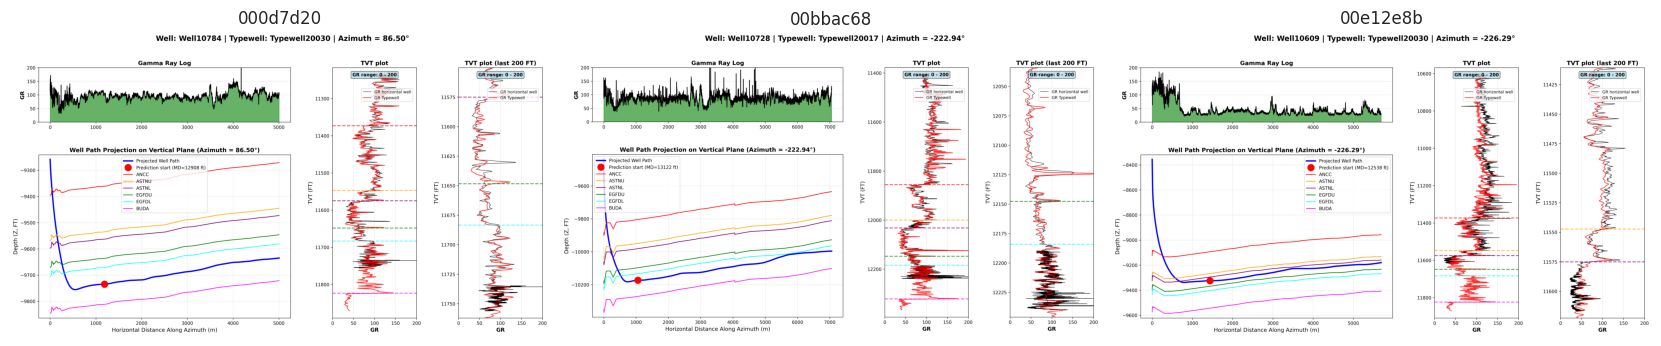

In [7]:
if train_png_paths:
    fig, axes = plt.subplots(1, len(sample_wells), figsize=(5.5 * len(sample_wells), 4), constrained_layout=True)
    if len(sample_wells) == 1:
        axes = [axes]

    for ax, well_id in zip(axes, sample_wells):
        path = png_path(well_id)
        if path.exists():
            img = plt.imread(path)
            ax.imshow(img)
            ax.set_title(well_id)
            ax.axis("off")
        else:
            ax.text(0.5, 0.5, f"No PNG for {well_id}", ha="center", va="center")
            ax.axis("off")
    plt.show()
else:
    print("No training PNG files found.")

## 6. How `TVT_input` Defines the Prediction Start

`TVT_input` is known before the prediction start and missing after it. In training, the true `TVT` remains available, so we can inspect the hidden/evaluation zone directly.

A good model should use the known TVT path, the horizontal well gamma ray (`GR`), the Typewell gamma ray, and spatial trajectory to infer the missing continuation.

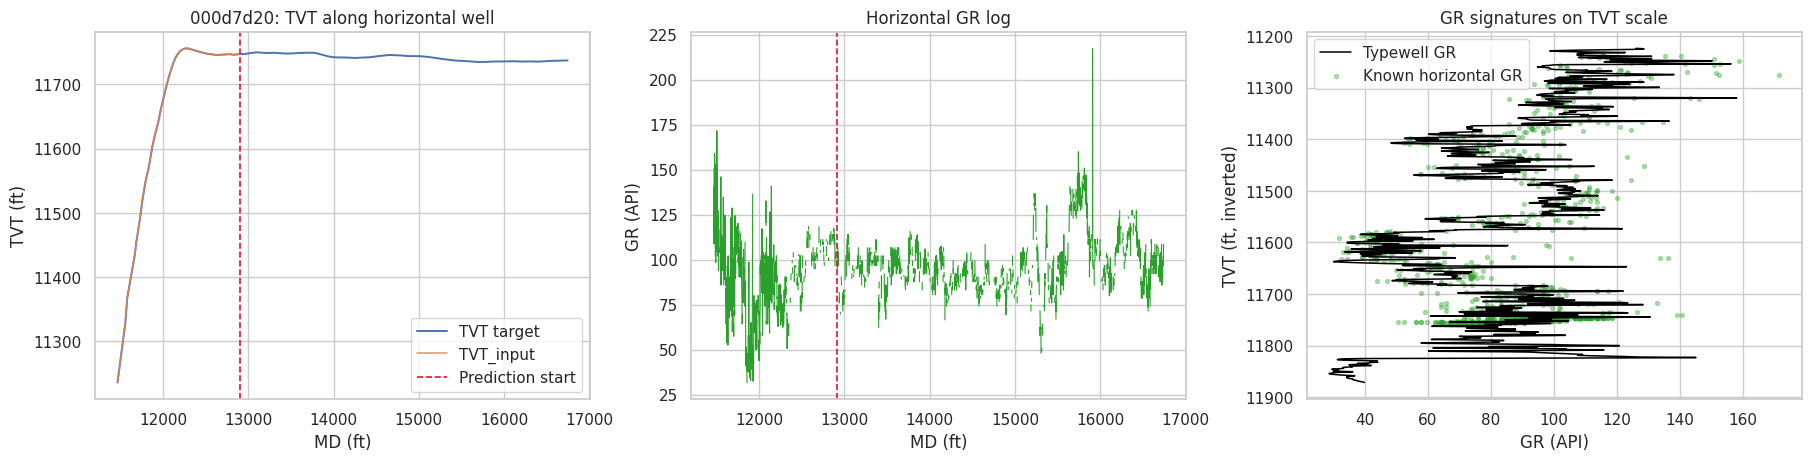

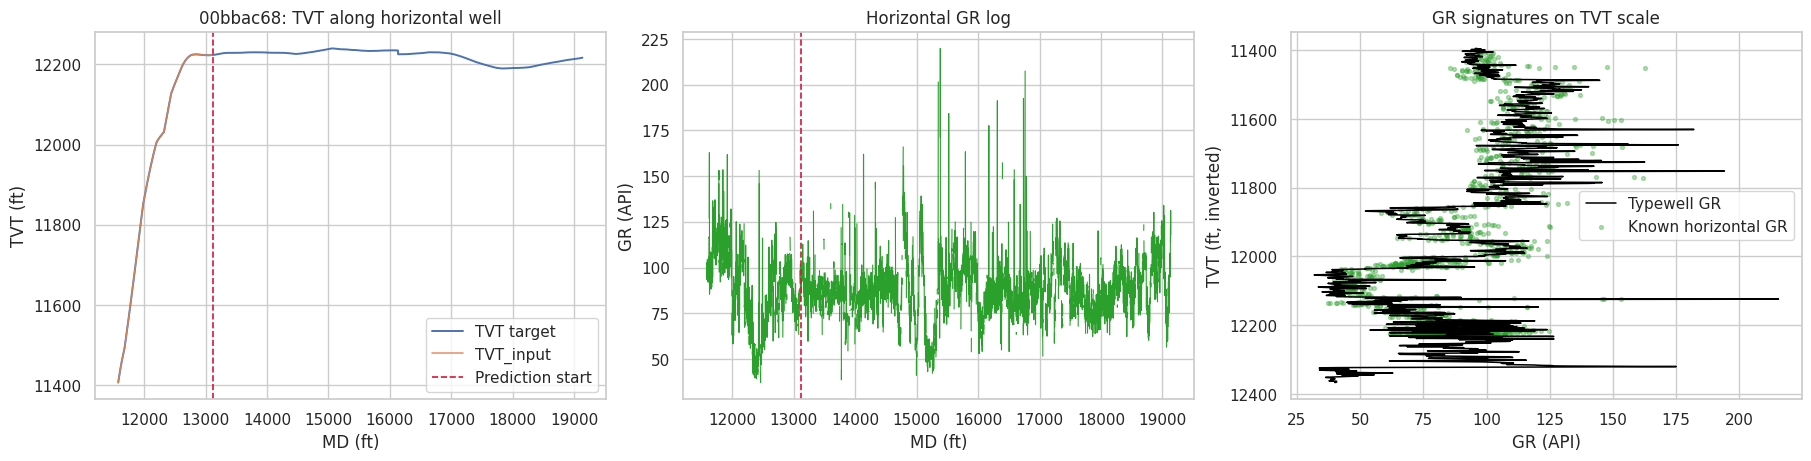

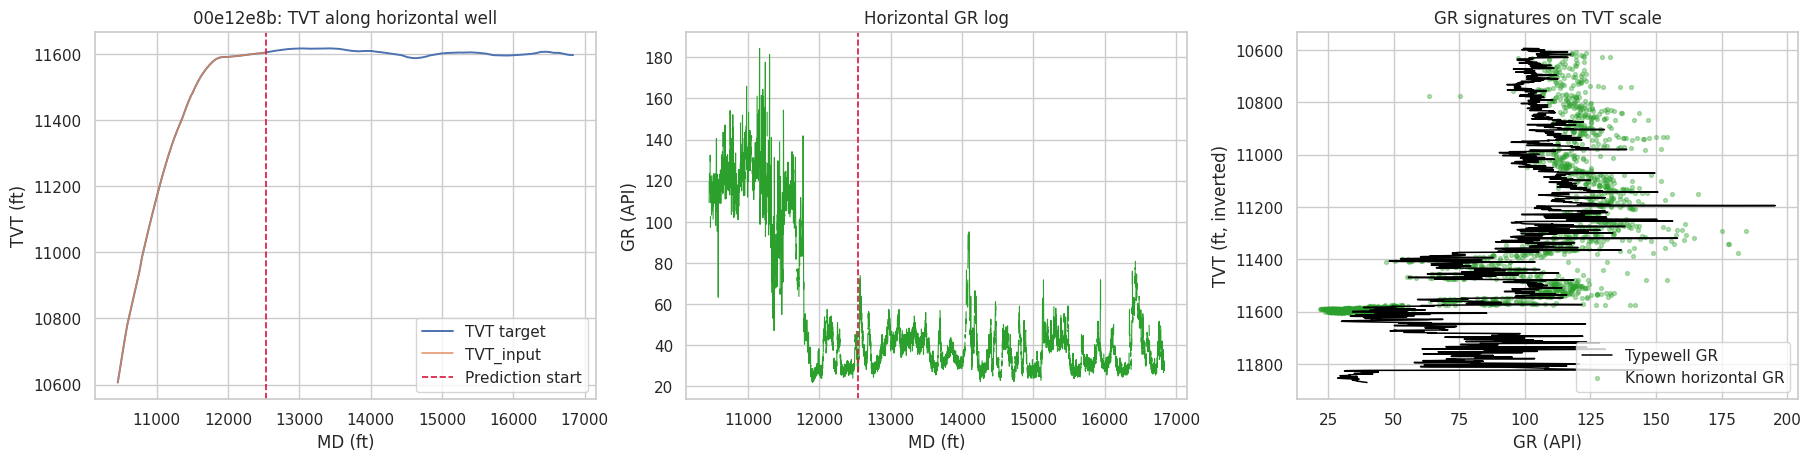

In [8]:
def first_missing_index(series):
    mask = series.isna()
    if not mask.any():
        return None
    return int(np.flatnonzero(mask.to_numpy())[0])

def plot_well_overview(well_id, split="train"):
    horizontal = load_horizontal(well_id, split=split)
    typewell = load_typewell(well_id, split=split)

    fig, axes = plt.subplots(1, 3, figsize=(18, 4.5), constrained_layout=True)

    # 1. Target path and provided input target.
    ax = axes[0]
    if "TVT" in horizontal.columns:
        ax.plot(horizontal["MD"], horizontal["TVT"], label="TVT target", lw=1.4)
    if "TVT_input" in horizontal.columns:
        ax.plot(horizontal["MD"], horizontal["TVT_input"], label="TVT_input", lw=1.1, alpha=0.9)
        ps_idx = first_missing_index(horizontal["TVT_input"])
        if ps_idx is not None:
            ax.axvline(horizontal.loc[ps_idx, "MD"], color="crimson", ls="--", lw=1.2, label="Prediction start")
    ax.set_title(f"{well_id}: TVT along horizontal well")
    ax.set_xlabel("MD (ft)")
    ax.set_ylabel("TVT (ft)")
    ax.legend(loc="best")

    # 2. Horizontal well gamma ray along measured depth.
    ax = axes[1]
    if "GR" in horizontal.columns:
        ax.plot(horizontal["MD"], horizontal["GR"], color="tab:green", lw=0.8)
    if "TVT_input" in horizontal.columns:
        ps_idx = first_missing_index(horizontal["TVT_input"])
        if ps_idx is not None:
            ax.axvline(horizontal.loc[ps_idx, "MD"], color="crimson", ls="--", lw=1.2)
    ax.set_title("Horizontal GR log")
    ax.set_xlabel("MD (ft)")
    ax.set_ylabel("GR (API)")

    # 3. Typewell GR vs TVT with known horizontal GR projected to TVT_input.
    ax = axes[2]
    if {"GR", "TVT"}.issubset(typewell.columns):
        ax.plot(typewell["GR"], typewell["TVT"], color="black", lw=1.1, label="Typewell GR")
    if {"GR", "TVT_input"}.issubset(horizontal.columns):
        known = horizontal[horizontal["TVT_input"].notna() & horizontal["GR"].notna()]
        ax.scatter(known["GR"], known["TVT_input"], s=8, alpha=0.35, color="tab:green", label="Known horizontal GR")
    ax.invert_yaxis()
    ax.set_title("GR signatures on TVT scale")
    ax.set_xlabel("GR (API)")
    ax.set_ylabel("TVT (ft, inverted)")
    ax.legend(loc="best")

    plt.show()

for well_id in sample_wells:
    plot_well_overview(well_id, split="train")

## 7. TVT Direction: Increasing, Decreasing, and Flat Segments

The task deck emphasizes that the same horizontal well can move up, down, or remain nearly flat in TVT. This matters because a model that assumes TVT always increases with `MD` will fail on wells where the lateral crosses dipping geology in the opposite direction.

The next cell samples training wells and looks at `dTVT / dMD` to show how often the target is increasing, decreasing, or nearly flat.

,direction,percent
0,nearly flat,52.128849
1,increasing,32.510479
2,decreasing,15.360673


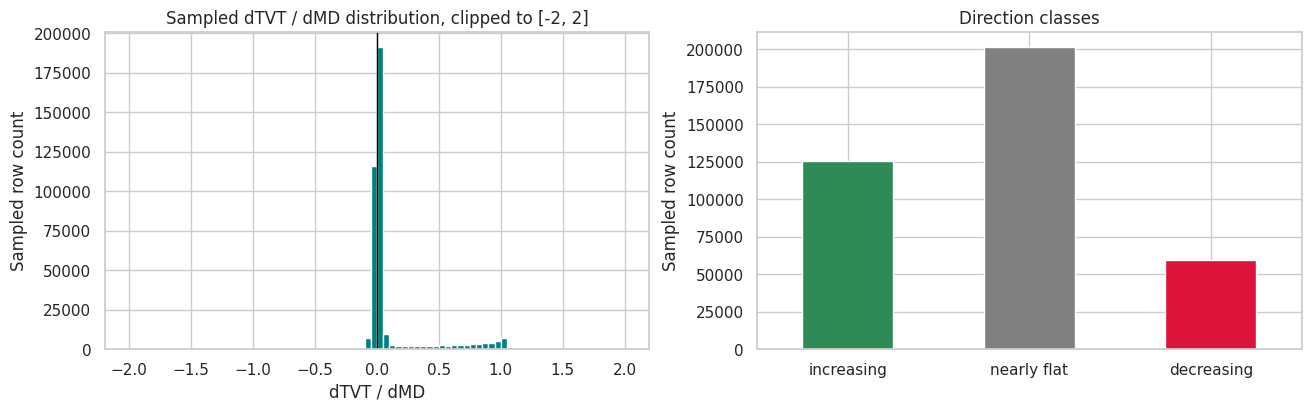

In [9]:
slope_rows = []

for i, path in enumerate(train_horizontal_paths):
    df = pd.read_csv(path, usecols=["MD", "TVT"])
    dmd = df["MD"].diff()
    dtvt = df["TVT"].diff()
    slope = (dtvt / dmd).replace([np.inf, -np.inf], np.nan).dropna()

    if len(slope) > 500:
        slope = slope.sample(500, random_state=RANDOM_STATE + i)

    slope_rows.append(pd.DataFrame({"well_id": well_id_from_path(path), "dTVT_dMD": slope}))

slope_df = pd.concat(slope_rows, ignore_index=True)
flat_eps = 0.02
slope_df["direction"] = np.select(
    [slope_df["dTVT_dMD"] > flat_eps, slope_df["dTVT_dMD"] < -flat_eps],
    ["increasing", "decreasing"],
    default="nearly flat",
)

display(slope_df["direction"].value_counts(normalize=True).mul(100).rename("percent").reset_index())

fig, axes = plt.subplots(1, 2, figsize=(13, 4), constrained_layout=True)
axes[0].hist(slope_df["dTVT_dMD"].clip(-2, 2), bins=80, color="teal", edgecolor="white")
axes[0].axvline(0, color="black", lw=1)
axes[0].set_title("Sampled dTVT / dMD distribution, clipped to [-2, 2]")
axes[0].set_xlabel("dTVT / dMD")
axes[0].set_ylabel("Sampled row count")

slope_df["direction"].value_counts().reindex(["increasing", "nearly flat", "decreasing"]).plot(
    kind="bar", ax=axes[1], color=["seagreen", "gray", "crimson"]
)
axes[1].set_title("Direction classes")
axes[1].set_xlabel("")
axes[1].set_ylabel("Sampled row count")
axes[1].tick_params(axis="x", rotation=0)
plt.show()

## 8. Dataset-Level Well Summary

The next cells summarize all training horizontal wells without concatenating the full dataset into one huge table. Each row of `train_summary` corresponds to one well.

In [10]:
def summarize_horizontal_file(path):
    df = pd.read_csv(path)
    well_id = well_id_from_path(path)

    result = {
        "well_id": well_id,
        "rows": len(df),
        "columns": len(df.columns),
    }

    for col in ["MD", "X", "Y", "Z", "TVT", "GR"]:
        if col in df.columns:
            result[f"{col}_min"] = df[col].min(skipna=True)
            result[f"{col}_max"] = df[col].max(skipna=True)
            result[f"{col}_range"] = result[f"{col}_max"] - result[f"{col}_min"]
            result[f"{col}_mean"] = df[col].mean(skipna=True)
            result[f"{col}_missing_pct"] = 100 * df[col].isna().mean()

    if "TVT_input" in df.columns:
        result["tvt_input_known_rows"] = int(df["TVT_input"].notna().sum())
        result["evaluation_rows"] = int(df["TVT_input"].isna().sum())
        result["evaluation_pct"] = 100 * df["TVT_input"].isna().mean()
        ps_idx = first_missing_index(df["TVT_input"])
        result["prediction_start_index"] = ps_idx
        result["prediction_start_md"] = np.nan if ps_idx is None else df.loc[ps_idx, "MD"]

    return result

train_summary = pd.DataFrame([summarize_horizontal_file(path) for path in train_horizontal_paths])
print(train_summary.shape)
display(train_summary.head())

(773, 38)


,well_id,rows,columns,MD_min,MD_max,MD_range,MD_mean,MD_missing_pct,X_min,X_max,X_range,X_mean,X_missing_pct,Y_min,Y_max,Y_range,Y_mean,Y_missing_pct,Z_min,Z_max,Z_range,Z_mean,Z_missing_pct,TVT_min,TVT_max,TVT_range,TVT_mean,TVT_missing_pct,GR_min,GR_max,GR_range,GR_mean,GR_missing_pct,tvt_input_known_rows,evaluation_rows,evaluation_pct,prediction_start_index,prediction_start_md
0,000d7d20,5278,13,11467.0,16744.0,5277.0,14105.5,0.0,2983468.41,2983578.28,109.87,2.983514e+06,0.0,1069022.09,1074040.56,5018.47,1.071418e+06,0.0,-9755.61,-9258.57,497.04,-9673.194324,0.0,11236.02,11756.12,520.10,11715.831127,0.0,31.765827,217.352257,185.586430,94.436961,42.781357,1442,3836,72.679045,1442,12909.0
1,00bbac68,7559,13,11578.0,19136.0,7558.0,15357.0,0.0,3005789.15,3010760.08,4970.93,3.008500e+06,0.0,1084504.44,1089521.36,5016.92,1.086928e+06,0.0,-10182.58,-9436.36,746.22,-10060.683338,0.0,11406.63,12240.01,833.38,12173.249467,0.0,37.132148,219.806788,182.674640,88.255106,12.461966,1545,6014,79.560788,1545,13123.0
2,00e12e8b,6384,13,10456.0,16839.0,6383.0,13647.5,0.0,2967726.49,2971071.98,3345.49,2.969569e+06,0.0,1060431.23,1065106.50,4675.27,1.062553e+06,0.0,-9338.34,-8356.04,982.30,-9192.323946,0.0,10606.18,11616.64,1010.46,11519.679511,0.0,21.892866,184.360973,162.468107,53.642421,9.147870,2083,4301,67.371554,2083,12539.0
3,015fe0d2,5950,13,11834.0,17783.0,5949.0,14808.5,0.0,2998620.50,3002003.09,3382.59,3.000247e+06,0.0,1073179.45,1077773.53,4594.08,1.075563e+06,0.0,-10231.85,-9537.66,694.19,-10087.174086,0.0,11747.26,12271.53,524.27,12223.226338,0.0,27.806823,201.041336,173.234512,87.957226,25.428571,1654,4296,72.201681,1654,13488.0
4,01869cd4,6850,13,11256.0,18105.0,6849.0,14680.5,0.0,2971669.40,2975650.09,3980.69,2.973618e+06,0.0,1063180.31,1068509.12,5328.81,1.065922e+06,0.0,-9643.35,-8961.39,681.96,-9492.844819,0.0,11358.27,11767.75,409.48,11733.212718,0.0,31.337161,182.482017,151.144855,86.964753,47.708029,1293,5557,81.124088,1293,12549.0


In [11]:
summary_cols = [
    "rows",
    "MD_range",
    "TVT_range",
    "GR_missing_pct",
    "tvt_input_known_rows",
    "evaluation_rows",
    "evaluation_pct",
]
summary_cols = [c for c in summary_cols if c in train_summary.columns]

display(train_summary[summary_cols].describe(percentiles=[0.05, 0.25, 0.5, 0.75, 0.95]).T)

,count,mean,std,min,5%,25%,50%,75%,95%,max
rows,773.0,6587.652005,1311.463547,2058.000000,4652.200000,5706.000000,6576.000000,7388.000000,8614.200000,12141.000000
MD_range,773.0,6586.652005,1311.463547,2057.000000,4651.200000,5705.000000,6575.000000,7387.000000,8613.200000,12140.000000
TVT_range,773.0,734.468926,175.484377,158.930000,449.292000,588.570000,758.220000,856.510000,996.984000,1256.700000
GR_missing_pct,773.0,29.385406,19.085710,0.652722,3.782269,12.119830,27.703783,46.395180,60.328048,80.098901
tvt_input_known_rows,773.0,1692.452781,217.343826,851.000000,1346.000000,1546.000000,1703.000000,1839.000000,2053.000000,2392.000000
evaluation_rows,773.0,4895.199224,1301.178409,407.000000,2947.400000,4044.000000,4840.000000,5694.000000,6918.400000,10052.000000
evaluation_pct,773.0,73.316082,6.377561,19.776482,62.470923,70.034423,73.999107,77.546187,81.946079,87.516484


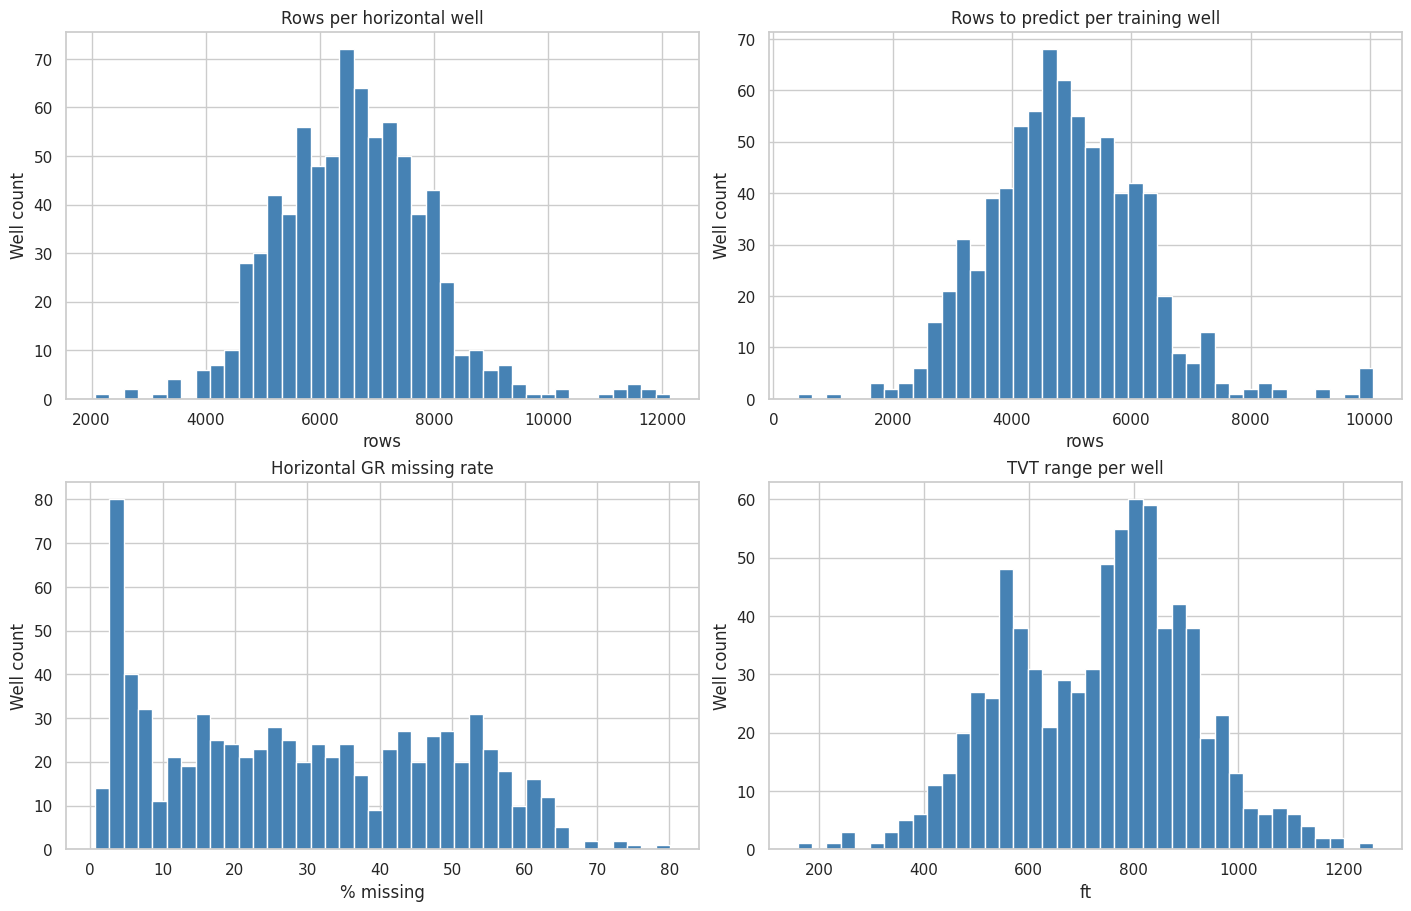

In [12]:
fig, axes = plt.subplots(2, 2, figsize=(14, 9), constrained_layout=True)
axes = axes.ravel()

plots = [
    ("rows", "Rows per horizontal well", "rows"),
    ("evaluation_rows", "Rows to predict per training well", "rows"),
    ("GR_missing_pct", "Horizontal GR missing rate", "% missing"),
    ("TVT_range", "TVT range per well", "ft"),
]

for ax, (col, title, xlabel) in zip(axes, plots):
    if col in train_summary.columns:
        ax.hist(train_summary[col].dropna(), bins=40, color="steelblue", edgecolor="white")
        ax.set_title(title)
        ax.set_xlabel(xlabel)
        ax.set_ylabel("Well count")
    else:
        ax.axis("off")

plt.show()

## 9. Map View: Offset-Well Context

The task deck also notes that neighboring wells can be useful because geological dip often behaves similarly over short distances. A simple first check is to plot well trajectories in `X`/`Y` space and identify nearby offsets.

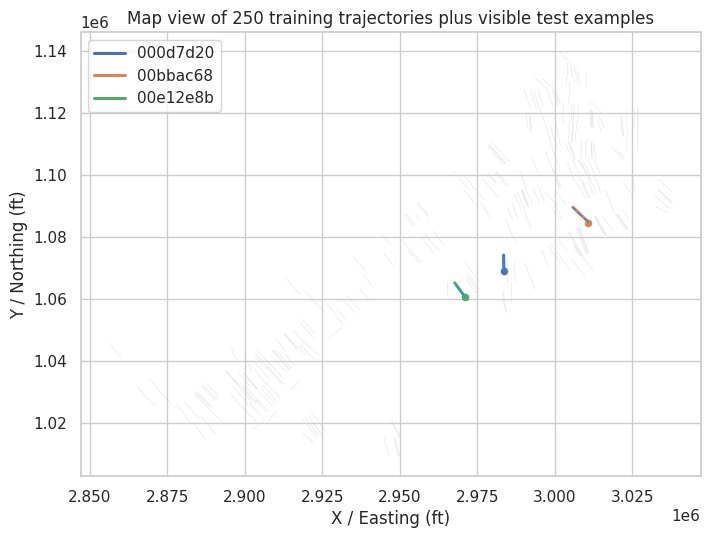

In [13]:
MAX_MAP_WELLS = 250
map_paths = train_horizontal_paths[:MAX_MAP_WELLS]

fig, ax = plt.subplots(figsize=(8, 8))

for path in map_paths:
    df = pd.read_csv(path, usecols=["X", "Y"])
    step = max(1, len(df) // 300)
    df = df.iloc[::step]
    ax.plot(df["X"], df["Y"], color="lightgray", lw=0.6, alpha=0.45)

for well_id in sample_wells:
    df = pd.read_csv(horizontal_path(well_id, "train"), usecols=["X", "Y"])
    ax.plot(df["X"], df["Y"], lw=2.2, label=well_id)
    ax.scatter(df["X"].iloc[0], df["Y"].iloc[0], s=20)

if test_horizontal_paths:
    for path in test_horizontal_paths:
        df = pd.read_csv(path, usecols=["X", "Y"])
        ax.plot(df["X"], df["Y"], color="dodgerblue", lw=1.2, ls="--", alpha=0.8)

ax.set_title(f"Map view of {len(map_paths)} training trajectories plus visible test examples")
ax.set_xlabel("X / Easting (ft)")
ax.set_ylabel("Y / Northing (ft)")
ax.set_aspect("equal", adjustable="box")
ax.legend(loc="best")
plt.show()

## 10. Missingness by Feature

Gamma ray can contain missing values. `TVT_input` is intentionally missing in the evaluation zone. In training, `TVT` is complete and can be used for validation experiments.

In [14]:
missing_counts = Counter()
nonmissing_counts = Counter()
column_totals = Counter()

for path in train_horizontal_paths:
    df = pd.read_csv(path)
    for col in df.columns:
        miss = int(df[col].isna().sum())
        missing_counts[col] += miss
        nonmissing_counts[col] += int(df[col].notna().sum())
        column_totals[col] += len(df)

missing_df = pd.DataFrame({
    "column": sorted(column_totals),
    "missing": [missing_counts[c] for c in sorted(column_totals)],
    "non_missing": [nonmissing_counts[c] for c in sorted(column_totals)],
    "total_rows_with_column": [column_totals[c] for c in sorted(column_totals)],
})
missing_df["missing_pct"] = 100 * missing_df["missing"] / missing_df["total_rows_with_column"]
missing_df = missing_df.sort_values("missing_pct", ascending=False)

display(missing_df)

,column,missing,non_missing,total_rows_with_column,missing_pct
9,TVT_input,3783989,1308266,5092255,74.308710
6,GR,1507972,3584283,5092255,29.613050
0,ANCC,45634,5046621,5092255,0.896145
4,EGFDL,6067,5086188,5092255,0.119142
1,ASTNL,0,5092255,5092255,0.000000
3,BUDA,0,5092255,5092255,0.000000
2,ASTNU,0,5092255,5092255,0.000000
7,MD,0,5092255,5092255,0.000000
5,EGFDU,0,5092255,5092255,0.000000
8,TVT,0,5092255,5092255,0.000000


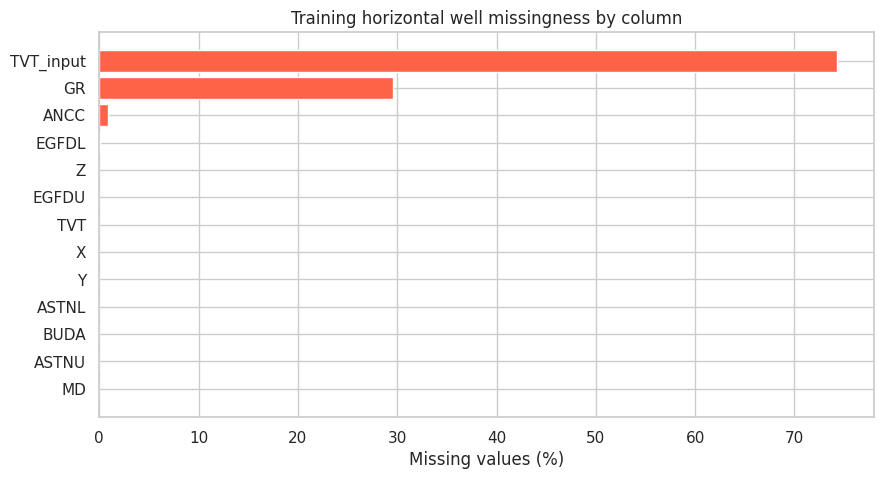

In [15]:
fig, ax = plt.subplots(figsize=(10, 5))
plot_df = missing_df.sort_values("missing_pct")
ax.barh(plot_df["column"], plot_df["missing_pct"], color="tomato")
ax.set_xlabel("Missing values (%)")
ax.set_title("Training horizontal well missingness by column")
plt.show()

## 11. Numeric Feature Correlations

This samples a small number of rows from each training well to inspect broad numeric relationships. Correlations are only a rough view here because the rows are sequential and wells are not independent IID rows.

In [16]:
numeric_cols = ["MD", "X", "Y", "Z", "ANCC", "ASTNU", "ASTNL", "EGFDU", "EGFDL", "BUDA", "TVT", "GR", "TVT_input"]
existing_numeric_cols = None
sampled_frames = []

for i, path in enumerate(train_horizontal_paths):
    df = pd.read_csv(path)
    cols = [c for c in numeric_cols if c in df.columns]
    df = df[cols]
    if len(df) > 200:
        df = df.sample(200, random_state=RANDOM_STATE + i)
    sampled_frames.append(df)

sampled_train = pd.concat(sampled_frames, ignore_index=True)
print(sampled_train.shape)
display(sampled_train.head())

(154600, 13)


,MD,X,Y,Z,ANCC,ASTNU,ASTNL,EGFDU,EGFDL,BUDA,TVT,GR,TVT_input
0,11475.0,2983525.35,1069023.85,-9266.37,-9395.36,-9569.41,-9597.19,-9670.54,-9705.51,-9845.90,11244.27,150.887678,11244.27
1,15713.0,2983482.23,1073010.75,-9652.25,-9290.62,-9464.67,-9492.45,-9565.80,-9600.77,-9741.16,11734.90,124.716969,NaN
2,12011.0,2983556.88,1069329.54,-9691.47,-9383.22,-9557.27,-9585.05,-9658.40,-9693.37,-9833.76,11681.49,71.572379,11681.49
3,13247.0,2983525.38,1070550.36,-9725.31,-9349.49,-9523.54,-9551.32,-9624.67,-9659.64,-9800.03,11749.08,92.229191,NaN
4,15407.0,2983483.39,1072705.48,-9661.29,-9297.05,-9471.10,-9498.88,-9572.23,-9607.20,-9747.59,11737.49,80.497494,NaN


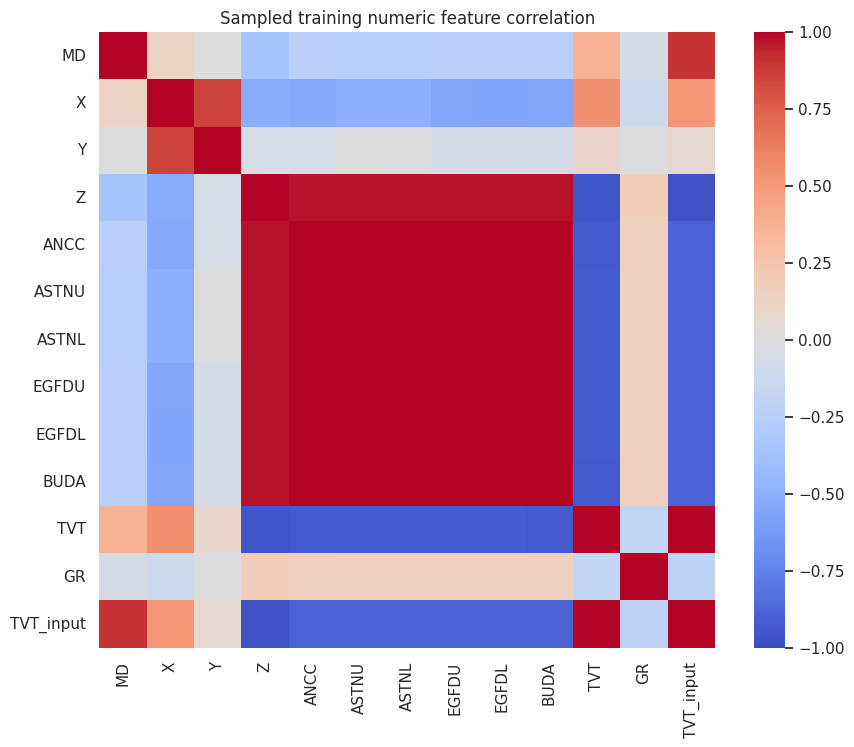

In [17]:
corr = sampled_train.corr(numeric_only=True)

fig, ax = plt.subplots(figsize=(10, 8))
if HAS_SEABORN:
    sns.heatmap(corr, cmap="coolwarm", center=0, vmin=-1, vmax=1, square=True, ax=ax)
else:
    im = ax.imshow(corr, cmap="coolwarm", vmin=-1, vmax=1)
    ax.set_xticks(range(len(corr.columns)))
    ax.set_xticklabels(corr.columns, rotation=90)
    ax.set_yticks(range(len(corr.index)))
    ax.set_yticklabels(corr.index)
    fig.colorbar(im, ax=ax, fraction=0.046, pad=0.04)
ax.set_title("Sampled training numeric feature correlation")
plt.show()

## 12. Typewell Exploration

Typewells are vertical reference logs. Their `GR` signatures can be matched against horizontal-well `GR` to infer where the horizontal well sits on the TVT/geology scale.

In [18]:
def summarize_typewell_file(path):
    df = pd.read_csv(path)
    result = {
        "well_id": well_id_from_path(path),
        "rows": len(df),
    }
    for col in ["TVT", "GR"]:
        if col in df.columns:
            result[f"{col}_min"] = df[col].min(skipna=True)
            result[f"{col}_max"] = df[col].max(skipna=True)
            result[f"{col}_range"] = result[f"{col}_max"] - result[f"{col}_min"]
            result[f"{col}_missing_pct"] = 100 * df[col].isna().mean()
    if "Geology" in df.columns:
        result["geology_missing_pct"] = 100 * df["Geology"].isna().mean()
        result["n_geology_labels"] = df["Geology"].dropna().nunique()
    return result

typewell_summary = pd.DataFrame([summarize_typewell_file(path) for path in train_typewell_paths])
print(typewell_summary.shape)
display(typewell_summary.head())

display(typewell_summary.describe(percentiles=[0.05, 0.25, 0.5, 0.75, 0.95]).T)

(773, 12)


,well_id,rows,TVT_min,TVT_max,TVT_range,TVT_missing_pct,GR_min,GR_max,GR_range,GR_missing_pct,geology_missing_pct,n_geology_labels
0,000d7d20,1296,11223.95,11871.45,647.5,0.0,28.66,158.18,129.52,0.0,23.070988,10
1,00bbac68,1946,11394.45,12366.95,972.5,0.0,31.86,215.44,183.58,0.0,47.379239,6
2,00e12e8b,2556,10593.95,11871.45,1277.5,0.0,28.66,195.42,166.76,0.0,60.993740,10
3,015fe0d2,1265,11734.95,12366.95,632.0,0.0,31.86,215.44,183.58,0.0,19.051383,6
4,01869cd4,1052,11345.95,11871.45,525.5,0.0,28.66,145.21,116.55,0.0,5.228137,10


,count,mean,std,min,5%,25%,50%,75%,95%,max
rows,773.0,2027.225097,1009.473248,636.00,1052.600,1498.000000,1874.000000,2158.000000,3918.00000,10043.000000
TVT_min,773.0,10828.526300,642.403977,9232.65,9976.170,10341.450000,10638.420000,11368.450000,11907.75000,12431.950000
TVT_max,773.0,11712.423920,633.834333,10236.85,10956.570,11145.280000,11537.410000,12202.950000,12874.68000,12991.530000
TVT_range,773.0,883.897620,185.034217,322.00,594.996,744.970000,907.490000,1012.000000,1168.08200,1399.000000
TVT_missing_pct,773.0,0.000000,0.000000,0.00,0.000,0.000000,0.000000,0.000000,0.00000,0.000000
GR_min,773.0,29.041889,5.968945,18.53,22.580,24.500000,28.290000,31.860000,38.91000,48.540000
GR_max,773.0,203.453959,39.196750,120.06,145.910,168.110000,207.010000,224.460000,273.82000,433.580000
GR_range,773.0,174.412070,38.084103,93.29,120.010,145.220000,175.830000,195.560000,234.91000,399.770000
GR_missing_pct,773.0,0.000000,0.000000,0.00,0.000,0.000000,0.000000,0.000000,0.00000,0.000000
geology_missing_pct,773.0,30.565909,16.382152,0.00,0.000,18.653199,35.075885,43.356273,52.56537,66.404308


,Geology,rows
0,ANCC,294268
1,EGFDL,205397
2,ASTNL,172223
3,BUDA,140640
4,ASTNU,118025
5,EGFDU,70013
6,OLMOS,23345
7,MNSS,5026
8,UPSN,2731
9,LBHL,1625


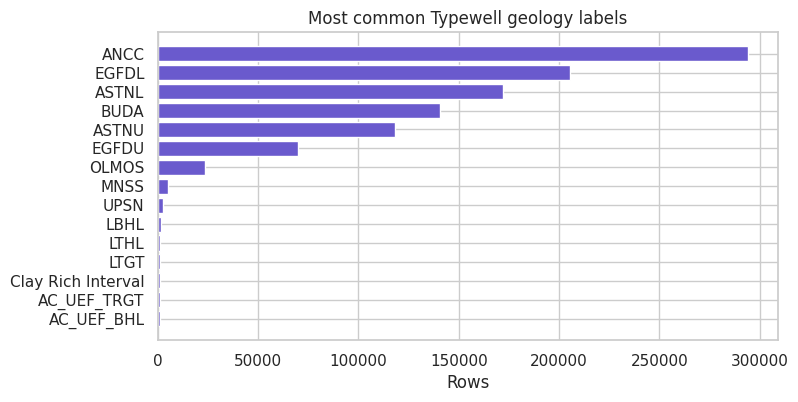

In [19]:
geology_counter = Counter()

for path in train_typewell_paths:
    df = pd.read_csv(path)
    if "Geology" in df.columns:
        geology_counter.update(df["Geology"].dropna().astype(str))

geology_counts = pd.DataFrame(geology_counter.most_common(), columns=["Geology", "rows"])
display(geology_counts)

if not geology_counts.empty:
    fig, ax = plt.subplots(figsize=(8, 4))
    top = geology_counts.head(15).sort_values("rows")
    ax.barh(top["Geology"], top["rows"], color="slateblue")
    ax.set_title("Most common Typewell geology labels")
    ax.set_xlabel("Rows")
    plt.show()

## 13. Sample Submission and Test Anatomy

The sample submission tells us exactly which rows need `tvt` predictions in the visible test folder. The `id` column uses `{well_id}_{row_index}`.

In [20]:
sub = pd.read_csv(SAMPLE_SUB_PATH)
sub["well_id"] = sub["id"].str.rsplit("_", n=1).str[0]
sub["row_index"] = sub["id"].str.rsplit("_", n=1).str[1].astype(int)

print(sub.shape)
display(sub.head())
display(sub.groupby("well_id").size().rename("submission_rows").reset_index())

(14151, 4)


,id,tvt,well_id,row_index
0,000d7d20_1442,0.0,000d7d20,1442
1,000d7d20_1443,0.0,000d7d20,1443
2,000d7d20_1444,0.0,000d7d20,1444
3,000d7d20_1445,0.0,000d7d20,1445
4,000d7d20_1446,0.0,000d7d20,1446


,well_id,submission_rows
0,000d7d20,3836
1,00bbac68,6014
2,00e12e8b,4301


In [21]:
test_rows = []
for path in test_horizontal_paths:
    well_id = well_id_from_path(path)
    df = pd.read_csv(path)
    row = {
        "well_id": well_id,
        "rows": len(df),
        "missing_TVT_input_rows": int(df["TVT_input"].isna().sum()) if "TVT_input" in df.columns else np.nan,
        "first_missing_index": first_missing_index(df["TVT_input"]) if "TVT_input" in df.columns else None,
        "has_target_TVT_column": "TVT" in df.columns,
    }
    test_rows.append(row)

test_summary = pd.DataFrame(test_rows)
display(test_summary)

,well_id,rows,missing_TVT_input_rows,first_missing_index,has_target_TVT_column
0,000d7d20,5278,3836,1442,False
1,00bbac68,7559,6014,1545,False
2,00e12e8b,6384,4301,2083,False


## 14. Practical Modeling Notes

A useful validation setup is to mimic test behavior on training wells: keep the known `TVT_input` segment, hide the evaluation zone, and score predictions against the training `TVT`.

Ideas worth exploring:

- Treat each well as a sequence, not as independent rows.
- Use `TVT_input` to estimate local TVT trend before the prediction start.
- Align horizontal `GR` to Typewell `GR` on the TVT scale, especially around the known segment.
- Use neighboring wells and spatial coordinates (`X`, `Y`, `Z`) to estimate dip and local geology trends.
- Handle missing `GR` explicitly; missingness itself may vary by well and segment.
- Validate by well, not by random row split, to avoid leakage across sequential rows from the same well.

This notebook is only an EDA starter. A strong solution will likely combine sequence alignment, spatial geology features, and well-level validation.